# 01 · Algorytm genetyczny w logistyce
## Najkrótsza trasa dostaw — od chromosomu do sprawdzonego wyniku



Firma ma jeden samochód, magazyn i 14 klientów. Samochód ma odwiedzić każdego klienta raz i wrócić do magazynu. Szukamy kolejności, która minimalizuje długość przejazdu.

To **w pełni rozwiązany notebook**: kod, tabele, wykresy, eksperymenty dodatkowe i interpretacje są gotowe. Wyniki wykonania są zapisane w pliku. Nie ma komórek do uzupełnienia.

**Po tym przykładzie potrafisz:** zakodować rozwiązanie jako permutację, zbudować selekcję turniejową, krzyżowanie OX i mutację inwersyjną, obserwować zbieżność i różnorodność populacji, porównać GA z heurystyką i wyznaczyć lukę względem optimum.

> Dane są syntetyczne. Współrzędne opisują umowną strefę dostaw w kilometrach. Nie są to adresy ani rzeczywiste odległości drogowe.

### Uruchomienie

Otwórz plik w Google Colab, JupyterLab lub VS Code i wybierz **Uruchom wszystkie / Run all**. Nie potrzeba klucza API, konta w usłudze trasowania ani plików danych. Wszystkie punkty są poniżej. Obliczenia po przygotowaniu środowiska nie korzystają z internetu.

W lokalnym środowisku potrzebujesz: `numpy`, `pandas`, `matplotlib`, `ipython` oraz Jupytera. W razie brakujących bibliotek uruchom w osobnej komórce: `%pip install numpy pandas matplotlib ipython`. Domyślny przykład jest celowo niewielki, aby dało się niezależnie policzyć optimum.

In [1]:
import sys
import time
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({
    'figure.dpi': 115,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.labelcolor': '#334155',
    'axes.grid': True,
    'grid.alpha': 0.18,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8fafc',
})
COLORS = {'ga': '#0f766e', 'base': '#64748b', 'exact': '#b45309', 'accent': '#7c3aed'}
pd.set_option('display.max_columns', 14)
pd.set_option('display.width', 150)
print(f'Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {matplotlib.__version__}')

Python 3.12.14 | NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8


### 1. Model decyzji i jego ograniczenia

Chromosom `r = [5, 2, 1, ...]` jest kolejnością klientów. Magazyn ma numer `0`, pozostaje poza chromosomem i jest automatycznie dopisywany na początku i końcu trasy.

\[
L(r)=d(0,r_1)+\sum_{i=1}^{n-1}d(r_i,r_{i+1})+d(r_n,0) \longrightarrow \min.
\]

**Założenia:** jeden pojazd; wszyscy klienci obowiązkowi; symetryczne odległości euklidesowe; brak ograniczeń ładowności i okien czasowych. To problem komiwojażera (TSP), będący uproszczonym modelem dostaw. Model pomija korki, ulice jednokierunkowe i czasy obsługi. Identyczny, stały czas obsługi każdego klienta nie zmieniłby najlepszej kolejności, ale wpłynąłby na czas zakończenia pracy.

14 klientów: 87,178,291,200 permutacji; po utożsamieniu kierunków przejazdu 43,589,145,600 różnych cykli.


,punkt,x_km,y_km
0,Magazyn,12,12
1,K01,2,3
2,K02,5,11
3,K03,2,21
4,K04,7,26
5,K05,10,18
6,K06,15,26
7,K07,21,23
8,K08,24,16
9,K09,21,10


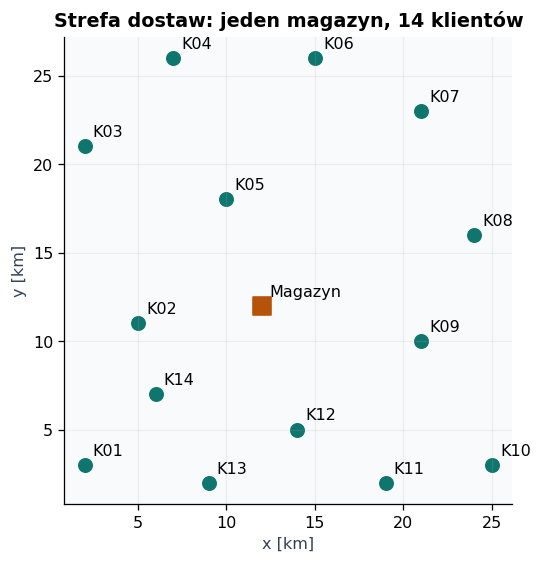

In [2]:
# Magazyn + 14 klientów. Jednostka obu osi: km.
points = pd.DataFrame({
    'punkt': ['Magazyn'] + [f'K{i:02d}' for i in range(1, 15)],
    'x_km': [12, 2, 5, 2, 7, 10, 15, 21, 24, 21, 25, 19, 14, 9, 6],
    'y_km': [12, 3, 11, 21, 26, 18, 26, 23, 16, 10, 3, 2, 5, 2, 7],
})
xy = points[['x_km', 'y_km']].to_numpy(dtype=float)
D = np.linalg.norm(xy[:, None, :] - xy[None, :, :], axis=2)
N = len(points) - 1
CLIENTS = np.arange(1, N + 1)

assert np.allclose(D, D.T) and np.allclose(np.diag(D), 0)
assert np.isfinite(D).all()
display(points)
print(f'{N} klientów: {math.factorial(N):,} permutacji; po utożsamieniu kierunków przejazdu {math.factorial(N)//2:,} różnych cykli.')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(xy[1:, 0], xy[1:, 1], s=70, c=COLORS['ga'])
ax.scatter(*xy[0], marker='s', s=135, c=COLORS['exact'], zorder=4)
for i, row in points.iterrows():
    ax.annotate(row['punkt'], xy[i], xytext=(5, 6), textcoords='offset points')
ax.set(xlabel='x [km]', ylabel='y [km]', title='Strefa dostaw: jeden magazyn, 14 klientów')
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

### 2. Funkcja celu: oceń trasę, nie wygląd chromosomu

Łączymy magazyn, klientów i powrót do magazynu. Każdy wiersz populacji jest jedną trasą. Funkcja poniżej ocenia całą populację naraz, korzystając z indeksowania NumPy.

Nie odwracamy długości do postaci `1 / L`: selekcja może bezpośrednio preferować mniejszą długość. Dzięki temu wynik ma czytelną jednostkę — kilometr.

In [3]:
def route_lengths(population, distance_matrix):
    population = np.atleast_2d(np.asarray(population, dtype=int))
    depot = np.zeros((len(population), 1), dtype=int)
    full = np.concatenate([depot, population, depot], axis=1)
    return distance_matrix[full[:, :-1], full[:, 1:]].sum(axis=1)


def route_length(route, distance_matrix=D):
    return float(route_lengths(route, distance_matrix)[0])


def route_is_valid(route, n=N):
    route = np.asarray(route)
    return route.shape == (n,) and np.array_equal(np.sort(route), np.arange(1, n + 1))


def draw_route(ax, route, title, color=COLORS['ga']):
    full = np.r_[0, route, 0]
    ax.plot(xy[full, 0], xy[full, 1], '-o', color=color, lw=1.7, ms=5)
    ax.scatter(*xy[0], marker='s', s=130, c=COLORS['exact'], zorder=4)
    for i in range(len(points)):
        ax.annotate(str(i), xy[i], xytext=(4, 5), textcoords='offset points', fontsize=8)
    ax.set(title=f'{title}\n{route_length(route):.2f} km', xlabel='x [km]', ylabel='y [km]')
    ax.set_aspect('equal')


demo_route = np.random.default_rng(123).permutation(CLIENTS)
print('Przykładowy chromosom:', demo_route)
print('Pełna trasa:', np.r_[0, demo_route, 0])
print(f'Długość: {route_length(demo_route):.2f} km; poprawna permutacja: {route_is_valid(demo_route)}')

Przykładowy chromosom: [ 8  3 13  1 12  9  5 11  2  6  7  4 10 14]
Pełna trasa: [ 0  8  3 13  1 12  9  5 11  2  6  7  4 10 14  0]
Długość: 227.39 km; poprawna permutacja: True


### 3. Punkty odniesienia

**Najbliższy sąsiad:** jedź do najbliższego jeszcze nieodwiedzonego klienta. Metoda jest szybka, lecz nie ocenia konsekwencji całej kolejności.

**Losowe przeszukiwanie:** wygeneruj wiele niezależnych tras i zapamiętaj najlepszą. Później przyznamy mu tyle samo ocen pełnych tras, ile wykona GA. To porównanie budżetu funkcji celu, a nie gwarancja równego czasu procesora. Osobno pokażemy czas wykonania.

In [4]:
def nearest_neighbor(distance_matrix):
    remaining = set(range(1, len(distance_matrix)))
    route, current = [], 0
    while remaining:
        next_node = min(remaining, key=lambda node: (distance_matrix[current, node], node))
        route.append(next_node)
        remaining.remove(next_node)
        current = next_node
    return np.array(route, dtype=int)


def random_search(distance_matrix, budget, seed=2026):
    rng = np.random.default_rng(seed)
    clients = np.arange(1, len(distance_matrix))
    best_route, best_length = None, np.inf
    # Porcje ograniczają zużycie pamięci również dla większego budżetu.
    for start in range(0, budget, 2000):
        size = min(2000, budget - start)
        population = np.array([rng.permutation(clients) for _ in range(size)])
        lengths = route_lengths(population, distance_matrix)
        idx = int(np.argmin(lengths))
        if lengths[idx] < best_length:
            best_route, best_length = population[idx].copy(), float(lengths[idx])
    return best_route, best_length


t0 = time.perf_counter()
nn_route = nearest_neighbor(D)
nn_seconds = time.perf_counter() - t0
print(f'Najbliższy sąsiad: {route_length(nn_route):.2f} km')

Najbliższy sąsiad: 108.73 km


### 4. Operatory dobrane do permutacji

| Element | Co robimy | Dlaczego |
|---|---|---|
| Selekcja turniejowa | Losujemy trzy osobniki i wybieramy najkrótszą trasę | Lepsze trasy częściej zostają rodzicami |
| Krzyżowanie OX | Zachowujemy fragment pierwszego rodzica, resztę uzupełniamy kolejnością drugiego | Nie gubimy i nie powielamy klientów |
| Mutacja inwersyjna | Odwracamy losowy fragment kolejności | Zmieniamy sąsiedztwo przy zachowaniu permutacji |
| Elityzm | Kopiujemy kilka najlepszych tras | Zachowujemy najlepszy znaleziony wynik |

Zwykłe sklejenie połowy jednego rodzica z połową drugiego może dać powtórzenia. W OX kolejność dopełnienia czytamy cyklicznie od końca skopiowanego fragmentu. Mutacja działa na **cały chromosom z danym prawdopodobieństwem**, a nie niezależnie na każdy gen.

In [5]:
def tournament(population, lengths, rng, k=3):
    candidates = rng.integers(0, len(population), size=k)
    winner = candidates[np.argmin(lengths[candidates])]
    return population[winner]


def order_crossover(parent_a, parent_b, rng):
    n = len(parent_a)
    # Dwie granice fragmentu; prawa granica nie należy do wycinka.
    left, right = np.sort(rng.choice(n + 1, size=2, replace=False))
    child = np.full(n, -1, dtype=int)
    child[left:right] = parent_a[left:right]
    kept = set(child[left:right])
    scan_b = np.r_[parent_b[right:], parent_b[:right]]
    fill_values = [int(gene) for gene in scan_b if gene not in kept]
    fill_positions = list(range(right, n)) + list(range(0, left))
    child[fill_positions] = fill_values
    return child


def inversion_mutation(route, rng, probability=0.35):
    child = route.copy()
    if rng.random() < probability:
        left, right = np.sort(rng.choice(len(child), size=2, replace=False))
        child[left:right + 1] = child[left:right + 1][::-1]
    return child


def unique_tour_fraction(population):
    # Przy symetrycznej macierzy trasa i jej odwrócenie to ten sam cykl.
    keys = {min(tuple(row), tuple(row[::-1])) for row in population}
    return len(keys) / len(population)


rng_demo = np.random.default_rng(8)
parent_a, parent_b = rng_demo.permutation(CLIENTS), rng_demo.permutation(CLIENTS)
child_ox = order_crossover(parent_a, parent_b, rng_demo)
child_mut = inversion_mutation(child_ox, rng_demo, probability=1.0)
display(pd.DataFrame([parent_a, parent_b, child_ox, child_mut],
                     index=['Rodzic A', 'Rodzic B', 'Dziecko OX', 'Dziecko po mutacji'],
                     columns=[f'Pozycja {i+1}' for i in range(N)]))
assert route_is_valid(child_ox) and route_is_valid(child_mut)

,Pozycja 1,Pozycja 2,Pozycja 3,Pozycja 4,Pozycja 5,Pozycja 6,Pozycja 7,Pozycja 8,Pozycja 9,Pozycja 10,Pozycja 11,Pozycja 12,Pozycja 13,Pozycja 14
Rodzic A,12,1,4,8,9,2,13,7,14,6,11,10,3,5
Rodzic B,13,3,6,7,11,12,9,1,2,14,8,4,10,5
Dziecko OX,13,6,7,11,12,9,1,2,14,8,4,10,3,5
Dziecko po mutacji,13,6,7,11,12,1,9,2,14,8,4,10,3,5


### 5. Pełna pętla algorytmu genetycznego

1. Losujemy populację poprawnych permutacji.
2. Obliczamy długości, zapisujemy najlepszą trasę, medianę i różnorodność.
3. Przenosimy elity, wybieramy rodziców, krzyżujemy i mutujemy potomstwo.
4. Powtarzamy do wykorzystania liczby pokoleń.

Pokolenie `0` to ocena populacji startowej. Dlatego liczba ocen wynosi `pop_size × (generations + 1)`. Elity również są ponownie oceniane. **Do startu nie dodajemy trasy najbliższego sąsiada ani wyniku dokładnego.**

`seed` kontroluje losowanie. Ten sam seed pozwala odtworzyć przebieg w tym samym środowisku; różne seedy pokazują stabilność metody.

In [6]:
def genetic_tsp(distance_matrix, pop_size=120, generations=220,
                crossover_probability=0.9, mutation_probability=0.35,
                elite_size=3, tournament_size=3, seed=7):
    n = len(distance_matrix) - 1
    assert n >= 2 and pop_size >= 4 and generations >= 1
    assert 1 <= elite_size < pop_size and tournament_size >= 1
    assert 0 <= crossover_probability <= 1 and 0 <= mutation_probability <= 1
    rng = np.random.default_rng(seed)
    population = np.array([rng.permutation(np.arange(1, n + 1)) for _ in range(pop_size)])
    history = []
    started = time.perf_counter()

    for generation in range(generations + 1):
        lengths = route_lengths(population, distance_matrix)
        order = np.argsort(lengths)
        history.append({
            'pokolenie': generation,
            'najlepsza_km': float(lengths[order[0]]),
            'mediana_km': float(np.median(lengths)),
            'udzial_roznych_tras': unique_tour_fraction(population),
        })
        if generation == generations:
            break

        next_population = [population[idx].copy() for idx in order[:elite_size]]
        while len(next_population) < pop_size:
            a = tournament(population, lengths, rng, tournament_size)
            b = tournament(population, lengths, rng, tournament_size)
            child = (order_crossover(a, b, rng)
                     if rng.random() < crossover_probability else a.copy())
            child = inversion_mutation(child, rng, mutation_probability)
            next_population.append(child)
        population = np.array(next_population)

    best_route = population[order[0]].copy()
    return {
        'route': best_route, 'length': float(lengths[order[0]]),
        'history': pd.DataFrame(history),
        'evaluations': pop_size * (generations + 1),
        'seconds': time.perf_counter() - started,
    }


CONFIG = dict(pop_size=120, generations=220, mutation_probability=0.35,
              crossover_probability=0.9, elite_size=3, tournament_size=3)
ga = genetic_tsp(D, seed=7, **CONFIG)
t0 = time.perf_counter()
random_route, random_length = random_search(D, ga['evaluations'])
random_seconds = time.perf_counter() - t0

print(f"GA: {ga['length']:.2f} km | {ga['evaluations']:,} ocen | {ga['seconds']:.2f} s")
print('Kolejność:', ' → '.join(points.loc[np.r_[0, ga['route'], 0], 'punkt']))
print(f'Losowe przeszukiwanie, ten sam budżet ocen: {random_length:.2f} km')

GA: 100.70 km | 26,520 ocen | 1.09 s
Kolejność: Magazyn → K02 → K14 → K01 → K13 → K12 → K11 → K10 → K09 → K08 → K07 → K06 → K04 → K03 → K05 → Magazyn
Losowe przeszukiwanie, ten sam budżet ocen: 146.04 km


### 6. Jak czytać przebieg uczenia populacji

Krzywa najlepszego wyniku pokazuje postęp wyszukiwania. Mediana opisuje typową trasę w populacji. Dzięki elityzmowi najlepsza długość nie powinna rosnąć.

Różnorodność to udział unikalnych cykli, z utożsamieniem trasy odwróconej. Wartość `1` oznacza, że wszystkie są różne; wartość bliska `0` wskazuje powtarzanie rozwiązań. Nie jest to miara różnorodności krawędzi — dwie różne trasy mogą być bardzo podobne.

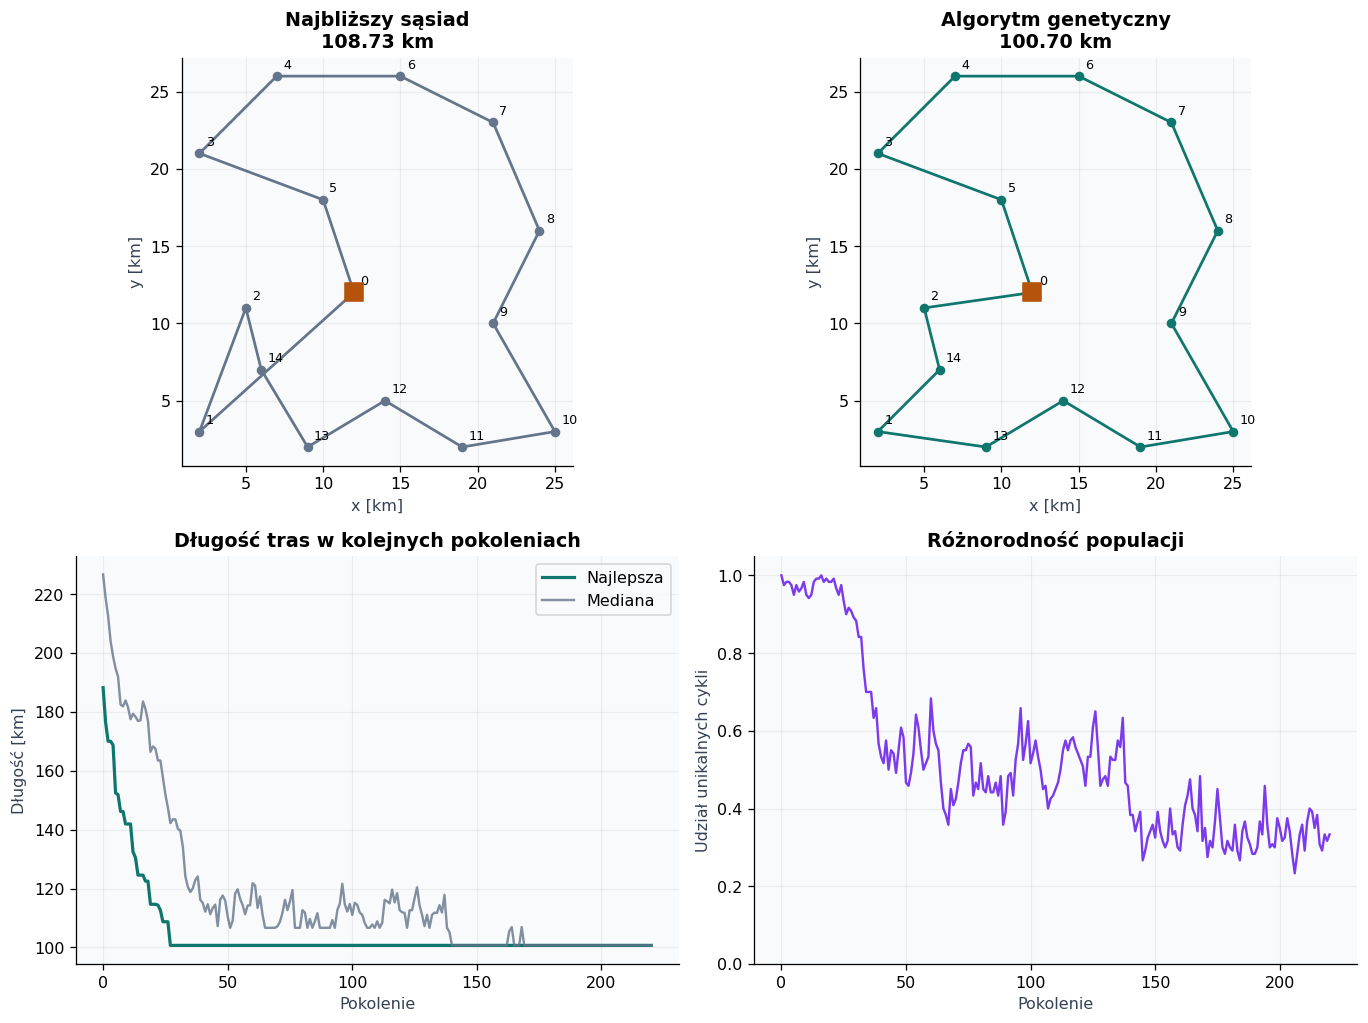

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
draw_route(axes[0, 0], nn_route, 'Najbliższy sąsiad', COLORS['base'])
draw_route(axes[0, 1], ga['route'], 'Algorytm genetyczny')
h = ga['history']
axes[1, 0].plot(h.pokolenie, h.najlepsza_km, label='Najlepsza', c=COLORS['ga'], lw=2)
axes[1, 0].plot(h.pokolenie, h.mediana_km, label='Mediana', c=COLORS['base'], alpha=0.8)
axes[1, 0].set(title='Długość tras w kolejnych pokoleniach', xlabel='Pokolenie', ylabel='Długość [km]')
axes[1, 0].legend()
axes[1, 1].plot(h.pokolenie, h.udzial_roznych_tras, c=COLORS['accent'])
axes[1, 1].set(title='Różnorodność populacji', xlabel='Pokolenie', ylabel='Udział unikalnych cykli', ylim=(0, 1.05))
fig.tight_layout()
plt.show()

### 7. Czy wynik GA jest rzeczywiście dobry? Liczymy optimum

Dla 14 klientów możemy jeszcze zastosować dokładne programowanie dynamiczne Held–Karpa. Stan `dp[S, j]` oznacza najkrótszą drogę z magazynu do klienta `j`, która odwiedziła dokładnie zbiór `S`:

\[
dp[S,j]=\min_{k\in S\setminus\{j\}}\big(dp[S\setminus\{j\},k]+d(k,j)\big).
\]

Na końcu dodajemy powrót do magazynu. To niezależna metoda: **nie dostaje rozwiązania GA i nie przekazuje go do populacji**. Jej koszt rośnie jak \(O(n^2 2^n)\), a pamięć jak \(O(n2^n)\). Dlatego poniżej jest zabezpieczenie przed przypadkowym uruchomieniem dużej instancji. Dokładność dotyczy naszego modelu odległości, nie rzeczywistych ulic.

In [8]:
def held_karp(distance_matrix):
    n = len(distance_matrix) - 1
    if not 1 <= n <= 16:
        raise ValueError('Wersja dydaktyczna obsługuje od 1 do 16 klientów.')
    dp = np.full((1 << n, n), np.inf)
    previous = np.full((1 << n, n), -1, dtype=np.int16)
    for j in range(n):
        dp[1 << j, j] = distance_matrix[0, j + 1]

    for mask in range(1, 1 << n):
        for j in range(n):
            if not (mask & (1 << j)):
                continue
            earlier_mask = mask ^ (1 << j)
            if earlier_mask == 0:
                continue
            best_cost, best_k = np.inf, -1
            remaining_bits = earlier_mask
            while remaining_bits:
                bit = remaining_bits & -remaining_bits
                k = bit.bit_length() - 1
                candidate = dp[earlier_mask, k] + distance_matrix[k + 1, j + 1]
                if candidate < best_cost:
                    best_cost, best_k = candidate, k
                remaining_bits ^= bit
            dp[mask, j], previous[mask, j] = best_cost, best_k

    mask = (1 << n) - 1
    final_costs = dp[mask] + distance_matrix[1:, 0]
    last = int(np.argmin(final_costs))
    optimum = float(final_costs[last])
    reverse_route = []
    while last != -1:
        reverse_route.append(last + 1)
        prev = int(previous[mask, last])
        mask ^= 1 << last
        last = prev
    return np.array(reverse_route[::-1], dtype=int), optimum


t0 = time.perf_counter()
optimal_route, optimal_length = held_karp(D)
exact_seconds = time.perf_counter() - t0
print(f'Optimum referencyjne: {optimal_length:.4f} km | czas: {exact_seconds:.2f} s')
print(f"Luka GA: {100 * (ga['length'] / optimal_length - 1):.4f}%")

Optimum referencyjne: 100.7008 km | czas: 0.26 s
Luka GA: 0.0000%


### 8. Rozwiązane rozszerzenie: lokalne poprawianie 2-opt

W symetrycznym TSP odwrócenie fragmentu trasy zmienia dwie krawędzie łączące go z resztą. W prostym 2-opt sprawdzamy takie odwrócenia i przyjmujemy pierwsze poprawiające rozwiązanie. Kończymy, kiedy żaden pojedynczy taki ruch nie pomaga.

Porównujemy **najbliższy sąsiad + 2-opt** i **GA + 2-opt**. Druga metoda to hybryda, więc nie przypisujemy jej całego wyniku samemu GA. Poniższa czytelna implementacja za każdym razem przelicza całą trasę; można ją przyspieszyć, licząc różnicę kosztu dwóch krawędzi.

,Metoda,Długość [km],Czas [s],Oceny tras / rodzaj pracy,Luka do optimum [%]
0,Losowe przeszukiwanie,146.0406,0.0613,26520,45.0242
1,Najbliższy sąsiad,108.7304,0.0001,wybory lokalnych krawędzi,7.9737
2,Najbliższy sąsiad + 2-opt,100.7008,0.0028,273 + budowa trasy,0.0000
3,GA,100.7008,1.0949,26520,0.0000
4,GA + 2-opt,100.7008,1.0959,26612,0.0000
5,Held–Karp: optimum,100.7008,0.2625,stany programowania dynamicznego,0.0000


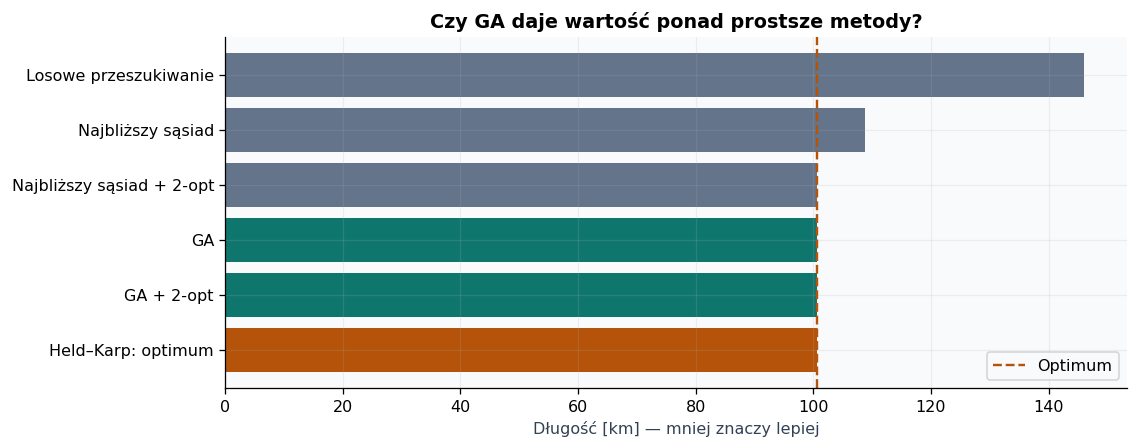

In [9]:
def two_opt(route, distance_matrix):
    best = route.copy()
    best_cost = route_length(best, distance_matrix)
    evaluations = 1
    while True:
        improved = False
        for left in range(len(best) - 1):
            for right in range(left + 1, len(best)):
                candidate = best.copy()
                candidate[left:right + 1] = candidate[left:right + 1][::-1]
                cost = route_length(candidate, distance_matrix)
                evaluations += 1
                if cost < best_cost - 1e-10:
                    best, best_cost, improved = candidate, cost, True
                    break
            if improved:
                break
        if not improved:
            return best, best_cost, evaluations


t0 = time.perf_counter()
nn_2opt, nn_2opt_length, nn_2opt_evals = two_opt(nn_route, D)
nn_2opt_seconds = time.perf_counter() - t0
t0 = time.perf_counter()
ga_2opt, ga_2opt_length, ga_2opt_evals = two_opt(ga['route'], D)
ga_2opt_seconds = time.perf_counter() - t0

comparison = pd.DataFrame([
    ['Losowe przeszukiwanie', random_length, random_seconds, str(ga['evaluations'])],
    ['Najbliższy sąsiad', route_length(nn_route), nn_seconds, 'wybory lokalnych krawędzi'],
    ['Najbliższy sąsiad + 2-opt', nn_2opt_length, nn_seconds + nn_2opt_seconds, f'{nn_2opt_evals} + budowa trasy'],
    ['GA', ga['length'], ga['seconds'], str(ga['evaluations'])],
    ['GA + 2-opt', ga_2opt_length, ga['seconds'] + ga_2opt_seconds, str(ga['evaluations'] + ga_2opt_evals)],
    ['Held–Karp: optimum', optimal_length, exact_seconds, 'stany programowania dynamicznego'],
], columns=['Metoda', 'Długość [km]', 'Czas [s]', 'Oceny tras / rodzaj pracy'])
comparison['Luka do optimum [%]'] = np.maximum(0, 100 * (comparison['Długość [km]'] / optimal_length - 1))
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
colors = [COLORS['base'], COLORS['base'], COLORS['base'], COLORS['ga'], COLORS['ga'], COLORS['exact']]
ax.barh(comparison['Metoda'], comparison['Długość [km]'], color=colors)
ax.axvline(optimal_length, c=COLORS['exact'], ls='--', label='Optimum')
ax.set(xlabel='Długość [km] — mniej znaczy lepiej', title='Czy GA daje wartość ponad prostsze metody?')
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

### 9. Rozwiązany eksperyment: pięć różnych ziaren losowych

Pojedyncze uruchomienie może być szczęśliwe albo pechowe. Uruchamiamy identyczny algorytm z pięcioma seedami. Raportujemy każdy wynik oraz minimum, medianę i maksimum. Pięć prób to demonstracja zmienności, nie pełny benchmark statystyczny. Wszystkie próby pracują na tej samej, jednej instancji problemu.

,Seed,Długość [km],Luka [%],Czas [s]
0,7,100.7008,0,1.0949
1,17,100.7008,0,0.9748
2,27,100.7008,0,0.9094
3,37,100.7008,0,0.8855
4,47,100.7008,0,0.8643


,Długość [km],Luka [%]
min,100.7008,0.0
median,100.7008,0.0
max,100.7008,0.0


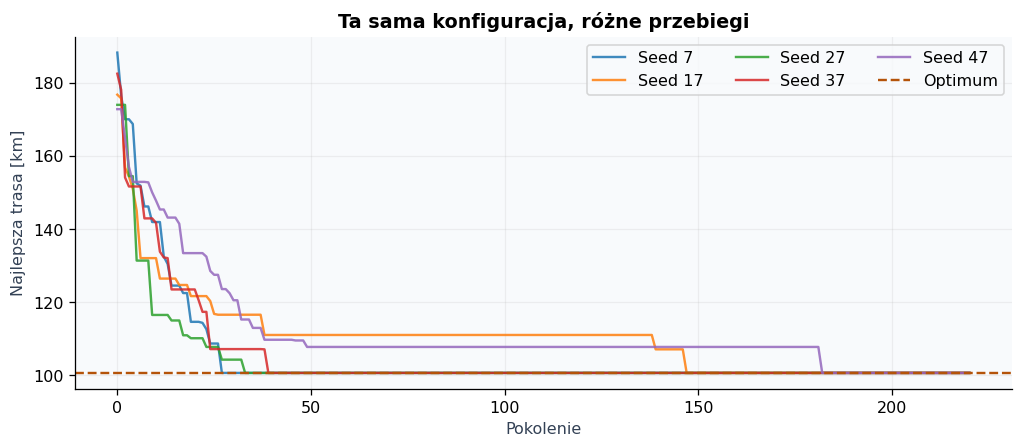

In [10]:
seeds = [7, 17, 27, 37, 47]
runs = {7: ga}
for seed in seeds[1:]:
    runs[seed] = genetic_tsp(D, seed=seed, **CONFIG)

stability = pd.DataFrame([
    {'Seed': seed, 'Długość [km]': result['length'],
     'Luka [%]': max(0, 100 * (result['length'] / optimal_length - 1)),
     'Czas [s]': result['seconds']}
    for seed, result in runs.items()
])
display(stability.round(4))
display(stability[['Długość [km]', 'Luka [%]']].agg(['min', 'median', 'max']).round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for seed, result in runs.items():
    ax.plot(result['history'].pokolenie, result['history'].najlepsza_km, label=f'Seed {seed}', alpha=0.85)
ax.axhline(optimal_length, c=COLORS['exact'], ls='--', label='Optimum')
ax.set(title='Ta sama konfiguracja, różne przebiegi', xlabel='Pokolenie', ylabel='Najlepsza trasa [km]')
ax.legend(ncol=3)
fig.tight_layout()
plt.show()

### 10. Rozwiązany eksperyment: co zmienia siła mutacji?

Porównujemy `0.05`, `0.35` i `0.80`. To prawdopodobieństwo odwrócenia fragmentu **u potomka**. Nie zmieniamy liczby pokoleń ani rozmiaru populacji. Dla każdego ustawienia stosujemy trzy seedy; wykorzystujemy już policzone wyniki dla `0.35`.

Mała mutacja może utrudniać wyjście z lokalnego minimum. Duża może utrudniać utrwalanie dobrych rozwiązań. Kierunek efektu trzeba sprawdzić, a nie założyć. Najlepsze ustawienie na tych punktach nie musi być najlepsze dla innych tras.

In [11]:
mutation_rows = []
for probability in [0.05, 0.35, 0.80]:
    for seed in seeds[:3]:
        config = {**CONFIG, 'mutation_probability': probability}
        result = runs[seed] if probability == 0.35 else genetic_tsp(D, seed=seed, **config)
        mutation_rows.append({
            'P(mutacji)': probability, 'Seed': seed,
            'Długość [km]': result['length'],
            'Luka [%]': max(0, 100 * (result['length'] / optimal_length - 1)),
            'Końcowa różnorodność': result['history'].udzial_roznych_tras.iloc[-1],
        })
mutation_results = pd.DataFrame(mutation_rows)
display(mutation_results.round(4))
display(mutation_results.groupby('P(mutacji)').agg(
    mediana_luki=('Luka [%]', 'median'),
    najgorsza_luka=('Luka [%]', 'max'),
    mediana_roznorodnosci=('Końcowa różnorodność', 'median'),
).round(4))

,P(mutacji),Seed,Długość [km],Luka [%],Końcowa różnorodność
0,0.05,7,100.7008,0.0000,0.0500
1,0.05,17,107.7970,7.0468,0.1083
2,0.05,27,111.0690,10.2960,0.0833
3,0.35,7,100.7008,0.0000,0.3333
4,0.35,17,100.7008,0.0000,0.3167
5,0.35,27,100.7008,0.0000,0.3500
6,0.80,7,100.7008,0.0000,0.9750
7,0.80,17,100.7008,0.0000,0.9833
8,0.80,27,100.7008,0.0000,0.9833


,mediana_luki,najgorsza_luka,mediana_roznorodnosci
P(mutacji),,,
0.05,7.0468,10.296,0.0833
0.35,0.0000,0.000,0.3333
0.80,0.0000,0.000,0.9833


### 11. Kontrole poprawności

Sprawdzamy zachowanie klientów przez operatory, niezwiększanie najlepszego kosztu, zgodność kosztu trasy referencyjnej z programowaniem dynamicznym i mały przypadek kwadratu o znanym obwodzie. To testy sensu rozwiązania, nie tylko sprawdzenie, że kod się uruchomił.

In [12]:
test_rng = np.random.default_rng(2026)
for _ in range(100):
    a, b = test_rng.permutation(CLIENTS), test_rng.permutation(CLIENTS)
    c = order_crossover(a, b, test_rng)
    assert route_is_valid(c)
    assert route_is_valid(inversion_mutation(c, test_rng, probability=1.0))
    assert route_is_valid(a) and route_is_valid(b)

assert route_is_valid(ga['route']) and route_is_valid(optimal_route)
assert np.all(np.diff(ga['history'].najlepsza_km) <= 1e-9)
assert np.isclose(route_length(optimal_route), optimal_length)
assert ga['length'] >= optimal_length - 1e-8
assert ga_2opt_length <= ga['length'] + 1e-8
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]], dtype=float)
square_D = np.linalg.norm(square[:, None, :] - square[None, :, :], axis=2)
square_route, square_optimum = held_karp(square_D)
assert np.isclose(square_optimum, 4.0)
assert np.isclose(route_length(square_route, square_D), 4.0)
print('OK: operatory, poprawność tras, elityzm, odniesienie dokładne i przypadek kontrolny.')

OK: operatory, poprawność tras, elityzm, odniesienie dokładne i przypadek kontrolny.


### 12. Automatyczne omówienie otrzymanych wyników

Poniższy tekst powstaje z rzeczywistych wyników tego uruchomienia. Po zmianie parametrów zaktualizuje się automatycznie. Jeżeli prosta heurystyka wygrywa z GA, wniosek brzmi: w tej konfiguracji warto użyć prostszej metody albo poprawić GA.

In [13]:
ga_gap = max(0, 100 * (ga['length'] / optimal_length - 1))
vs_nn = 100 * (route_length(nn_route) - ga['length']) / route_length(nn_route)
assessment = ('GA skrócił trasę najbliższego sąsiada' if vs_nn >= 0
              else 'GA uzyskał trasę dłuższą od trasy najbliższego sąsiada')
display(Markdown(f"""
**Wynik główny:** GA znalazł trasę **{ga['length']:.2f} km**, przy optimum **{optimal_length:.2f} km**.
Luka wynosi **{ga_gap:.3f}%**. {assessment} o **{abs(vs_nn):.2f}%**.

**Stabilność:** w pięciu uruchomieniach mediana luki wyniosła **{stability['Luka [%]'].median():.3f}%**,
a najgorsza luka **{stability['Luka [%]'].max():.3f}%**.

**Hybryda:** końcowe 2-opt zmieniło wynik GA z **{ga['length']:.2f}** do **{ga_2opt_length:.2f} km**.
Wynik metody najbliższego sąsiada z 2-opt to **{nn_2opt_length:.2f} km**.
To porównanie pozwala ocenić, czy koszt ewolucji był na tej instancji uzasadniony.

**Znaczenie biznesowe:** różnica **{route_length(nn_route) - ga['length']:.2f} km** względem trasy bazowej
jest wynikiem modelu euklidesowego. Nie należy zamieniać jej w rzeczywistą oszczędność paliwa
bez przeliczenia tras po sieci drogowej.
"""))


**Wynik główny:** GA znalazł trasę **100.70 km**, przy optimum **100.70 km**.
Luka wynosi **0.000%**. GA skrócił trasę najbliższego sąsiada o **7.38%**.

**Stabilność:** w pięciu uruchomieniach mediana luki wyniosła **0.000%**,
a najgorsza luka **0.000%**.

**Hybryda:** końcowe 2-opt zmieniło wynik GA z **100.70** do **100.70 km**.
Wynik metody najbliższego sąsiada z 2-opt to **100.70 km**.
To porównanie pozwala ocenić, czy koszt ewolucji był na tej instancji uzasadniony.

**Znaczenie biznesowe:** różnica **8.03 km** względem trasy bazowej
jest wynikiem modelu euklidesowego. Nie należy zamieniać jej w rzeczywistą oszczędność paliwa
bez przeliczenia tras po sieci drogowej.


### Głębsze dno: czego ten przykład uczy o ewolucji?

**Wartość genu zależy od kontekstu.** Klient `7` nie jest „dobrym genem”. Liczy się to, z kim sąsiaduje. To przykład epistazy: jakość fragmentu rozwiązania zależy od innych fragmentów. Krzyżowanie OX chroni kolejność, ale nie musi zachować wszystkich dobrych krawędzi.

**Reprezentacja wyznacza możliwe błędy.** Permutacja od razu wymusza jednokrotną wizytę. Gdybyśmy użyli dowolnych liczb całkowitych, musielibyśmy naprawiać brakujących i powtórzonych klientów. Wybór chromosomu często jest ważniejszy niż dopracowanie prawdopodobieństwa mutacji.

**Zbieżność nie jest dowodem optymalności.** Płaska krzywa oznacza tylko, że algorytm przestał poprawiać wynik w swoim budżecie. Tutaj optimum znamy dzięki innej metodzie. W dużym zadaniu potrzebujemy dolnego ograniczenia, benchmarku albo mocnego konkurencyjnego solvera.

**Losowość jest narzędziem wyszukiwania.** Algorytm nie ma mapy wszystkich rozwiązań ani świadomości dostaw. Selekcja przesuwa rozkład generowanych tras. Elityzm chroni najlepszy wynik, ale nie gwarantuje zachowania różnorodności.

**Kiedy użyć w praktyce?** Najpierw zbuduj macierz rzeczywistych kosztów przejazdu. Dla jednego pojazdu i prostego TSP sprawdź też wyspecjalizowane metody. Przy wielu pojazdach, ładowności i oknach czasowych zmienia się model problemu — samo dodanie klientów do tego notebooka nie tworzy kompletnego systemu planowania floty.

### Gotowe odpowiedzi do dyskusji

- **Dlaczego magazyn nie jest genem?** Jego położenie na początku i końcu jest ustalone; nie ma sensu go optymalizować.
- **Dlaczego dwie przeciwne kolejności mogą mieć ten sam koszt?** Odległości są symetryczne. Dla ulic jednokierunkowych taka równoważność może zniknąć; wtedy trzeba zmienić też miarę różnorodności.
- **Dlaczego GA nie zawsze wygrywa z 2-opt?** Ten mały, geometryczny problem bardzo sprzyja lokalnemu poprawianiu. Złożona metoda nie dostaje premii za złożoność.
- **Co zmienić dla własnych danych?** Tablicę `points` lub macierz `D`; następnie uruchomić całość ponownie. Dla ponad 16 klientów pominąć referencję Held–Karpa i wszystkie komórki wymagające jej wyniku albo zastąpić ją odpowiednią referencją. Pozostały kod GA obsługuje większe permutacje.

**Źródła i samodzielne rozwinięcia:** kod algorytmów w tym notebooku jest kompletny i napisany bez biblioteki GA. Definicję losowania z ustalonym ziarnem opisuje [dokumentacja NumPy Generator](https://numpy.org/doc/stable/reference/random/generator.html). Konwencja `dp[S,j]` została w całości wyjaśniona i zaimplementowana powyżej.